In [1]:
import sys
import os

__file__ = "/Users/jmfrutos/github/ISL-python/ISL/examples"
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))

from ISL.isl import ts_invariant_statistical_loss, ts_invariant_statistical_loss_2, CondTimeGenModel, generated_fictitious
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions import Normal
import math


In [9]:
class RecurrentRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RecurrentRNN, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers = 2, dropout=0.0)
        self.bn_rnn = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.bn_fc = nn.BatchNorm1d(output_size)
        self.activation_fc = nn.ReLU()  # Activation after the fully connected layer

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.bn_rnn(out[:, -1, :])  # Batch normalization on the output of LSTM
        out = self.fc(out)
        out = self.bn_fc(out)  # Batch normalization on the output of the fully connected layer
        out = self.activation_fc(out)  # Applying ReLU activation after the fully connected layer
        return out

class GeneratorNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GeneratorNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.bn2 = nn.BatchNorm1d(output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)  # Batch normalization after the first linear layer
        out = self.relu(out)
        out = self.fc2(out)
        return out

output_size = 10
# Initialize models
rec = RecurrentRNN(input_size=1, hidden_size=64, output_size=output_size)
gen = GeneratorNN(input_size= output_size + 1, hidden_size=64, output_size=1)

model = CondTimeGenModel(rec, gen)
#model = torch.compile(model)

In [3]:
class RecurrentRNNAttention(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_heads=16):
        super(RecurrentRNNAttention, self).__init__()
        self.linear = nn.Linear(input_size, hidden_size)  # Replace RNN with a Linear layer
        self.attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, batch_first=True)
        self.bn_linear = nn.BatchNorm1d(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        self.bn_fc = nn.BatchNorm1d(output_size)
        self.activation_fc = nn.ELU()  # Activation after the fully connected layer

    def forward(self, x):
        linear_out = self.linear(x)  # linear_out: [batch_size, seq_len, hidden_size]
        
        # Applying multi-head attention
        attn_out, _ = self.attention(linear_out, linear_out, linear_out)  # self-attention
        
        # Pooling the attention output (using mean pooling here, can also try max or sum)
        pooled_attn_out = torch.mean(attn_out, dim=1)  # [batch_size, hidden_size]
        
        # Batch normalization on the attention-pooled output
        out = self.bn_linear(pooled_attn_out)
        out = self.fc(out)
        out = self.bn_fc(out)  # Batch normalization on the output of the fully connected layer
        out = self.activation_fc(out)  # Applying ReLU activation after the fully connected layer
        return out
        

output_size = 32
# Initialize models
rec = RecurrentRNNAttention(input_size=1, hidden_size=128, output_size=output_size)
gen = GeneratorNN(input_size= output_size + 1, hidden_size=128, output_size=1)

model = CondTimeGenModel(rec, gen)

In [4]:
import pandas as pd

# Define the path to your file
file_path = '/Users/jmfrutos/github/ISL-python/data/LD2011_2014.txt'

# Load the data
# Assuming the first row contains headers and the first column contains datetime information
data = pd.read_csv(file_path, sep=';', index_col=0, parse_dates=True, decimal=',')

In [5]:
start_date = '2012-01-01'
end_date = '2012-02-01'

selected_columns = data.loc[:, 'MT_001':'MT_001']

first_non_zero_index_MT_001 = data['MT_001'].ne(0).idxmax()
X_t = selected_columns[first_non_zero_index_MT_001:] # Your time series data
Y_t = selected_columns[data['MT_001'].index > first_non_zero_index_MT_001] # Your shifted time series data by one time step

X_t = X_t.loc[start_date:end_date]
Y_t = Y_t.loc[start_date:end_date]

# Remove `NaN` values and interpolate them in X_t
X_t = X_t.interpolate(method='linear').dropna()

# Remove `NaN` values and interpolate them in Y_t
Y_t = Y_t.interpolate(method='linear').dropna()

# Optionally, align X_t and Y_t if necessary
X_t, Y_t = X_t.align(Y_t, join='inner')

def z_score_normalize(df):
    """Normalize a pandas DataFrame so that each column has mean 0 and std 1."""
    return (df - df.mean()) / df.std()

X_t = z_score_normalize(X_t)
Y_t = z_score_normalize(Y_t)

X_t_tensor = torch.tensor(X_t.values, dtype=torch.float32)
Y_t_tensor = torch.tensor(Y_t.values, dtype=torch.float32)


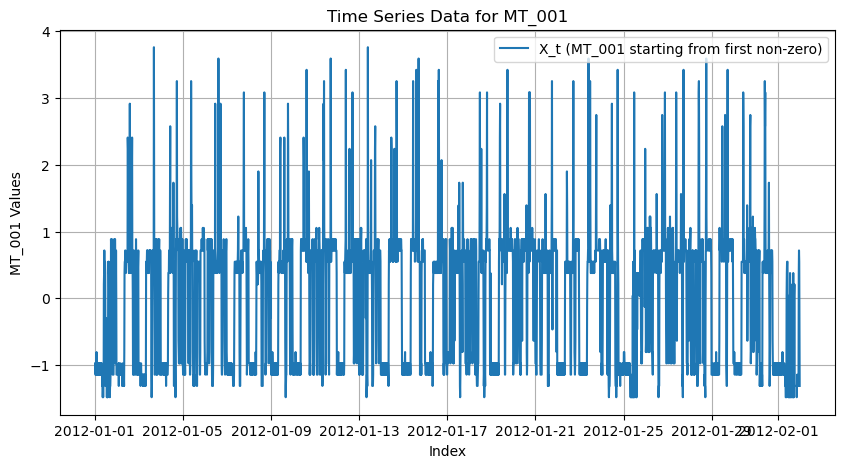

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(X_t.loc[start_date:end_date], label='X_t (MT_001 starting from first non-zero)')
#plt.plot(Y_t.index, Y_t.values, label='Y_t (MT_001 > first non-zero index)', linestyle='--')
plt.xlabel('Index')
plt.ylabel('MT_001 Values')
plt.title('Time Series Data for MT_001')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
noise_model = Normal(0.0, 1.0)
hparams = {
    'max_k': 10,
    'samples': 1000,
    'epochs': 100,
    'eta': 1e-2,
    'transform': noise_model,
    'window_size': 1000,
    'K': 10
}

# Train the model using the ts_invariant_statistical_loss function
loader_Xt = DataLoader(X_t_tensor, batch_size=hparams['samples'], shuffle=False, drop_last=True)
loader_Yt = DataLoader(Y_t_tensor, batch_size=hparams['samples'], shuffle=False, drop_last=True)

losses = []
for i in range(10):
    loss = ts_invariant_statistical_loss_2(model, loader_Xt, loader_Yt, hparams)
    losses.append(loss)

100%|██████████| 3/3 [00:08<00:00,  2.74s/it]


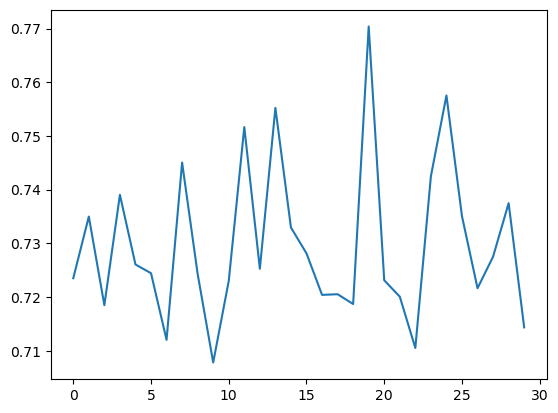

In [14]:
losses = np.array(losses)
plt.plot(losses.flatten())

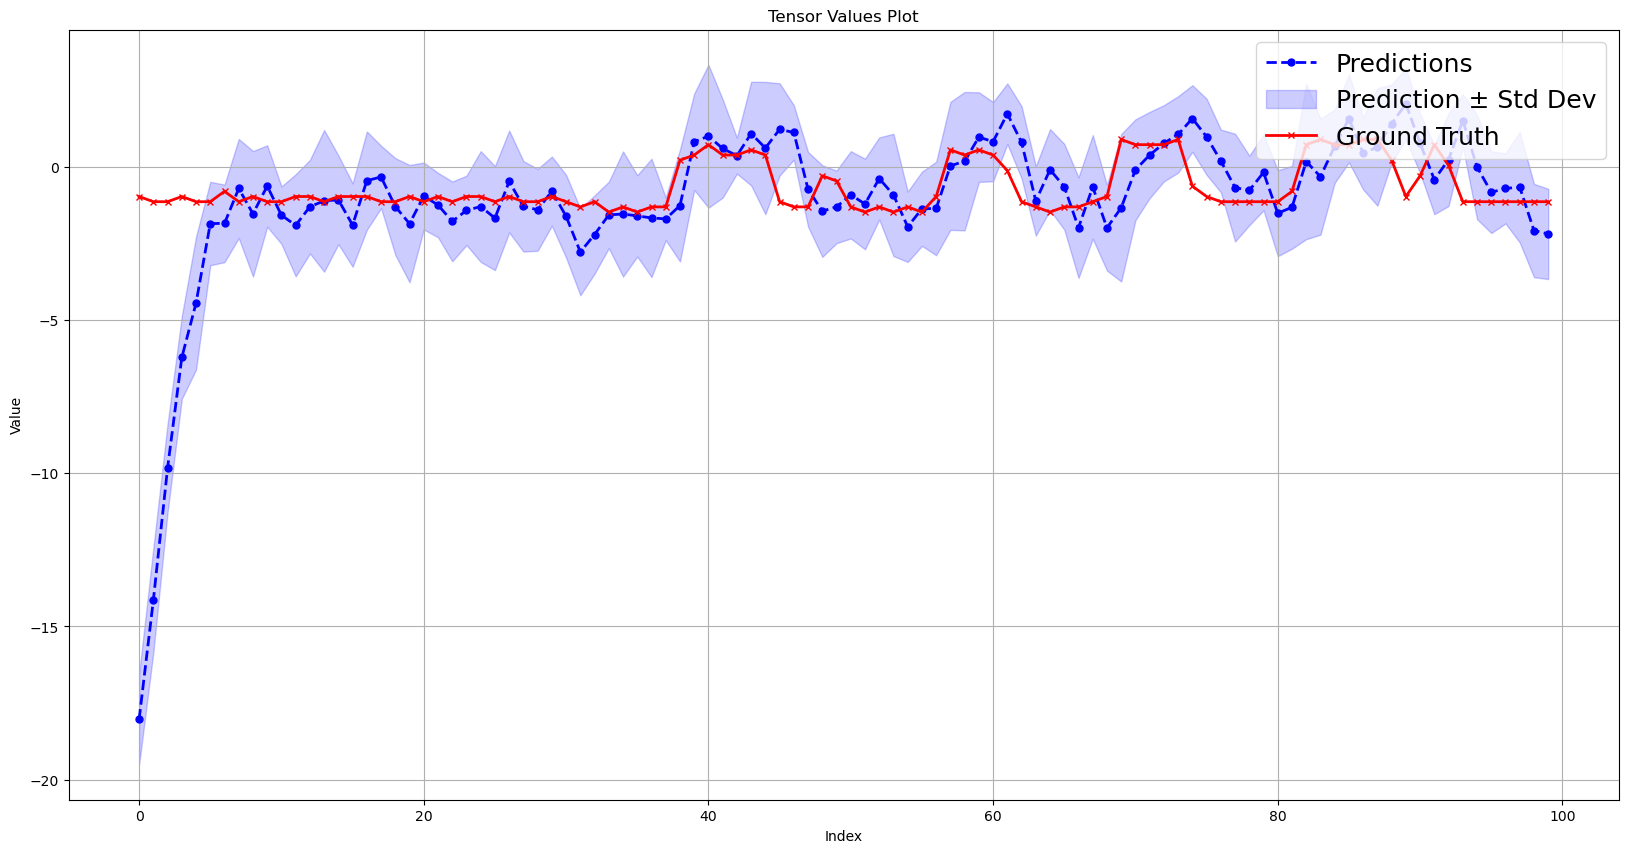

In [17]:
total_samples = 100
input_tensor = next(iter(loader_Xt)).unsqueeze(2).float()
y_k = generated_fictitious(model, input_tensor, hparams['K'])
prediction = np.array([torch.mean(y_k[i:i+hparams['K']]).item() for i in range(0, len(y_k), hparams['K'])])[0:total_samples]
prediction_std = np.array([torch.std(y_k[i:i+hparams['K']]).item() for i in range(0, len(y_k), hparams['K'])])[0:total_samples]

# Convert tensors to a list of floats
data = np.array([t for t in Y_t.values.flatten()])
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
ground_truth = (data - mean) / std

# Plot the data
plt.figure(figsize=(20, 10))
# Plot the generated data with a different line style and color
plt.plot(prediction, label='Predictions', linestyle='--', color='blue', linewidth=2, marker='o', markersize=5)

plt.fill_between(
    np.arange(len(prediction)), 
    prediction - prediction_std, 
    prediction + prediction_std, 
    color='blue', 
    alpha=0.2, 
    label='Prediction ± Std Dev'
)

# Plot the normalized data with a contrasting color and line style
plt.plot(ground_truth[0:total_samples], label='Ground Truth', color='red', linewidth=2, marker='x', markersize=5)
plt.title('Tensor Values Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend(fontsize=18, loc='upper right')
plt.grid(True)
plt.show()